#Bài tập trên lớp

2.1. Nạp thư viện


In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input

# Data visualization packages
import matplotlib.pyplot as plt

2.2. Đọc dữ liệu MNIST

In [4]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'

df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print("Kích thước df_train:", df_train.shape)

# Tách features (X) và labels (y)
X_train = df_train.iloc[:, 1:]
y_train = df_train.iloc[:, 0]

X_test = df_test.iloc[:, 1:]
y_test = df_test.iloc[:, 0]

print("Kích thước các tập dữ liệu ban đầu:")
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

num_classes = 10
input_shape = (28, 28, 1)

# Chuẩn hóa dữ liệu về khoảng [0, 1]
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# Chuyển đổi sang mảng numpy và thay đổi kích thước thành dạng ảnh (28x28x1)
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print("Kích thước X_train sau reshape:", X_train.shape)

X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print("Kích thước X_test sau reshape:", X_test.shape)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print("5 nhãn đầu tiên của tập train:\n", y_train[:5])


Kích thước df_train: (19999, 785)
Kích thước các tập dữ liệu ban đầu:
(19999, 784) (19999,) (9999, 784) (9999,)
Kích thước X_train sau reshape: (19999, 28, 28, 1)
Kích thước X_test sau reshape: (9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
5 nhãn đầu tiên của tập train:
 0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


2.3. Trực quan hóa 10 ảnh đầu tiên

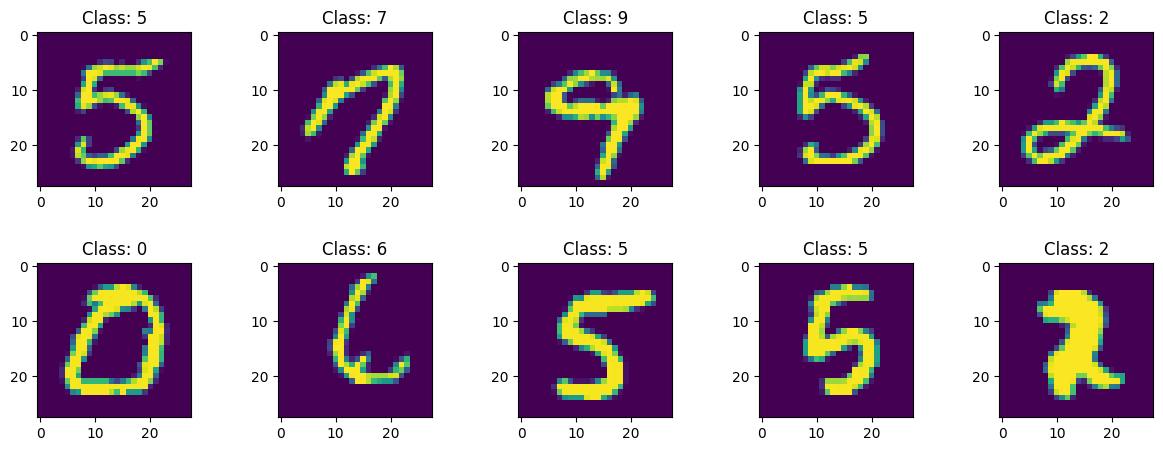

In [6]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()

for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text("Class: " + str(y_train[i]))

plt.subplots_adjust(hspace=0.5)
plt.show()

2.4. Chuyển giá trị nhãn thành one-hot encoding

In [7]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

2.5. Xây dựng mô hình CNN

In [8]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

2.6. Huấn luyện mô hình CNN

In [9]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 114ms/step - accuracy: 0.8283 - loss: 0.6282 - val_accuracy: 0.9435 - val_loss: 0.2116
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 111ms/step - accuracy: 0.9544 - loss: 0.1527 - val_accuracy: 0.9560 - val_loss: 0.1484
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 108ms/step - accuracy: 0.9705 - loss: 0.1002 - val_accuracy: 0.9680 - val_loss: 0.1065
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 23s 127ms/step - accuracy: 0.9759 - loss: 0.0780 - val_accuracy: 0.9680 - val_loss: 0.0987
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 113ms/step - accuracy: 0.9814 - loss: 0.0625 - val_accuracy: 0.9745 - val_loss: 0.0856
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - accuracy: 0.9858 - loss: 0.0507 - val_accuracy: 0.9710 - val_loss: 0.0938
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.9860 - loss: 0.0459 - val_accuracy: 0.9740 - val_loss: 0.0888
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - accuracy: 0.9868 - loss: 0.

2.7. Đánh giá mô hình CNN (Vẽ đồ thị)

In [ ]:
# Đồ thị Accuracy
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Đồ thị Loss
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

2.8. Đánh giá mô hình CNN thử nghiệm trên tập test

In [ ]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2.9. Dự báo nhãn cho ảnh sử dụng CNN

In [ ]:
predict = model.predict(X_test[:1])
print("Xác suất dự báo cho ảnh đầu tiên:\n", predict)
print("Nhãn dự đoán:", np.argmax(predict), "| Nhãn thực tế:", np.argmax(y_test[0]))

plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

2.10. Lưu tham số mô hình CNN

In [ ]:
model.save_weights('cnn.h5')

2.11. Nạp lại mô hình và tham số

In [ ]:
# Định nghĩa lại kiến trúc mạng
model_reloaded = Sequential()
model_reloaded.add(Input(shape=input_shape))
model_reloaded.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model_reloaded.add(MaxPool2D(pool_size=(2, 2)))
model_reloaded.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model_reloaded.add(MaxPool2D(pool_size=(2, 2)))
model_reloaded.add(Flatten())
model_reloaded.add(Dense(units=10, activation='softmax'))

# Nạp lại trọng số đã lưu
model_reloaded.load_weights('cnn.h5')

# Dự đoán thử nghiệm trên ảnh thứ 2 (chỉ số 1:2)
predict_reloaded = model_reloaded.predict(X_test[1:2])
print("Xác suất dự báo từ mô hình nạp lại:\n", predict_reloaded)
print("Nhãn dự đoán:", np.argmax(predict_reloaded), "| Nhãn thực tế:", np.argmax(y_test[1]))

plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()

#Bài tập về nhà

Câu 1

In [10]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1. Load data CIFAR10 có sẵn
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# 2. Chuẩn hóa dữ liệu ảnh về khoảng [0, 1]
X_train, X_test = X_train / 255.0, X_test / 255.0

# 3. Định nghĩa các nhãn tương ứng (Label từ 0-9)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 4. Xây dựng cấu trúc mạng CNN cho ảnh 3D (32x32x3)
model_cifar = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 lớp đầu ra
])

# 5. Compile và huấn luyện mô hình
model_cifar.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

print("--- BẮT ĐẦU HUẤN LUYỆN CIFAR10 ---")
history_cifar = model_cifar.fit(X_train, y_train, epochs=10,
                                batch_size=64, validation_split=0.1)

# 6. Đánh giá trên tập kiểm tra
test_loss, test_acc = model_cifar.evaluate(X_test, y_test, verbose=2)
print(f'\nCIFAR10 Test accuracy: {test_acc:.4f}')

# 7. Lưu mô hình lại để dùng cho câu 5 (Web Flask)
model_cifar.save('cifar10_model.h5')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
--- BẮT ĐẦU HUẤN LUYỆN CIFAR10 ---
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 71s 98ms/step - accuracy: 0.4331 - loss: 1.5491 - val_accuracy: 0.5256 - val_loss: 1.3088
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.5743 - loss: 1.2017 - val_accuracy: 0.6256 - val_loss: 1.0876
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 83ms/step - accuracy: 0.6331 - loss: 1.0437 - val_accuracy: 0.6500 - val_loss: 1.0011
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 81ms/step - accuracy: 0.6679 - loss: 0.9471 - val_accuracy: 0.6548 - val_loss: 0.9795
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 81ms/step - accuracy: 0.6918 - loss: 0.8776 - val_accuracy: 0.6718 - val_loss: 0.9514
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 85ms/step - accuracy: 0.7125 - loss: 0.8190 - val_accuracy: 0.6988 - val_loss: 0.9029
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 81ms/step - accuracy: 0.7343 - loss: 0.7631 - val_accuracy: 0.7218 - val_loss: 0.8343
Ep


CIFAR10 Test accuracy: 0.6882


Câu 4

In [11]:
# 1. Load data Fashion-MNIST có sẵn
(X_train_f, y_train_f), (X_test_f, y_test_f) = datasets.fashion_mnist.load_data()

# 2. Chuẩn hóa và reshape vì ảnh gốc là (28x28), cần đưa về (28x28x1) để chạy mạng CNN
X_train_f = X_train_f.reshape(-1, 28, 28, 1) / 255.0
X_test_f = X_test_f.reshape(-1, 28, 28, 1) / 255.0

# 3. Xây dựng mạng CNN
model_fashion = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_fashion.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

print("\n--- BẮT ĐẦU HUẤN LUYỆN FASHION-MNIST ---")
model_fashion.fit(X_train_f, y_train_f, epochs=10, batch_size=64, validation_split=0.1)

# Save model lại phục vụ câu 5
model_fashion.save('fashion_model.h5')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- BẮT ĐẦU HUẤN LUYỆN FASHION-MNIST ---
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 58s 67ms/step - accuracy: 0.8266 - loss: 0.4881 - val_accuracy: 0.8710 - val_loss: 0.3474
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 67s 80ms/step - accuracy: 0.8835 - loss: 0.3259 - val_accuracy: 0.8870 - val_loss: 0.3071
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 61s 54ms/step - accuracy: 0.8968 - loss: 0.2809 - val_accuracy: 0.8973 - val_loss: 0.2736
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 56ms/step - accuracy: 0.9082 - loss: 0.2504 - val_accuracy: 0.9013 - val_loss: 0.2823
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 56ms/step - accuracy: 0.9160 - loss: 0.2282 - val_accuracy: 0.9043 - val_loss: 0.2579
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9242 - loss: 0.2034 - val_accuracy: 0.9077 - val_los

Câu 2

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory

# 1. Cấu hình đường dẫn và thông số ảnh
train_dir = 'data_cat_dog/train'
val_dir = 'data_cat_dog/val'
BATCH_SIZE = 32
IMG_SIZE = (128, 128) # Resize toàn bộ ảnh về cỡ 128x128 để xử lý đồng bộ

# 2. Load tự động dữ liệu từ thư mục
train_dataset = image_dataset_from_directory(
    train_dir, batch_size=BATCH_SIZE, image_size=IMG_SIZE, shuffle=True
)
val_dataset = image_dataset_from_directory(
    val_dir, batch_size=BATCH_SIZE, image_size=IMG_SIZE, shuffle=False
)

# 3. Xây dựng kiến trúc CNN phân loại nhị phân (Binary Classification)
model_dogcat = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255), # Chuẩn hóa pixel ngay trong mô hình

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Dùng sigmoid vì chỉ có 2 lớp (0 hoặc 1)
])

# 4. Compile với loss là binary_crossentropy
model_dogcat.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

print("\n--- BẮT ĐẦU HUẤN LUYỆN CAT VS DOG ---")
model_dogcat.fit(train_dataset, validation_data=val_dataset, epochs=10)

# 5. Lưu model lại
model_dogcat.save('dogcat_model.h5')

FileNotFoundError: [Errno 2] No such file or directory: 'data_cat_dog/train'

Câu 4

In [ ]:
# Cấu hình đường dẫn dữ liệu khuôn mặt Nam/Nữ
face_train_dir = 'data_face/train'
face_val_dir = 'data_face/val'

train_face_ds = image_dataset_from_directory(face_train_dir, batch_size=32, image_size=(128, 128))
val_face_ds = image_dataset_from_directory(face_val_dir, batch_size=32, image_size=(128, 128))

model_face = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Phân loại nhị phân Nam/Nữ
])

model_face.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\n--- BẮT ĐẦU HUẤN LUYỆN FACE GENDER ---")
model_face.fit(train_face_ds, validation_data=val_face_ds, epochs=10)

model_face.save('gender_model.h5')

Câu 5

In [ ]:
from flask import Flask, render_template, request, jsonify
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import os

app = Flask(__name__)

# Tải model đã được train ở Câu 1 lên hệ thống web
MODEL_PATH = 'cifar10_model.h5'
model = load_model(MODEL_PATH)

# Danh sách nhãn tương ứng của bộ CIFAR10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

@app.route('/', methods=['GET'])
def index():
    # Hiển thị trang giao diện upload ảnh ban đầu
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    if 'file' not in request.files:
        return "Vui lòng chọn một file ảnh hợp lệ!"

    file = request.files['file']
    if file.filename == '':
        return "Chưa có ảnh nào được tải lên!"

    if file:
        # Tạo đường dẫn lưu ảnh tạm thời mà người dùng upload lên
        upload_dir = 'static/uploads'
        if not os.path.exists(upload_dir):
            os.makedirs(upload_dir)

        filepath = os.path.join(upload_dir, file.filename)
        file.save(filepath)

        # Tiền xử lý ảnh giống như lúc đem đi train (Đưa về kích thước 32x32)
        img = image.load_img(filepath, target_size=(32, 32))
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0) # Thêm chiều batch_size

        # Dự đoán kết quả
        predictions = model.predict(img_array)
        score = tf.nn.softmax(predictions[0]) # Lấy xác suất phân phối
        predicted_class = class_names[np.argmax(score)]
        confidence = 100 * np.max(score)

        # Trả kết quả về giao diện hiển thị cho người dùng
        return f"<h3>Kết quả dự đoán: <span style='color:blue'>{predicted_class}</span> ({confidence:.2f}%)</h3><br><a href='/'>Quay lại</a>"

if __name__ == '__main__':
    app.run(debug=True, port=5000)